In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [72]:
# 2. Read datasets
toraman22 = pd.read_csv('initial_datasets/Toraman22_hate_speech_v2.tsv', sep='\t')
offensTR = pd.read_csv('initial_datasets/offensTR.csv')
jigsaw = pd.read_csv('initial_datasets/jigsaw.csv')


/tmp/ipykernel_7843/4170887266.py:2: DtypeWarning: Columns (0,4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  toraman22 = pd.read_csv('initial_datasets/Toraman22_hate_speech_v2.tsv', sep='\t')


In [73]:
import re

def replace_urls(text):
    if not isinstance(text, str): return text
    url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
    return url_pattern.sub('URLTOKEN', text)

# 3. Modify toraman22
columns_to_keep = ['tweet_id', 'text', 'language', 'label', 'label_0', 'label_1', 'label_2', 'label_score']
toraman22 = toraman22[columns_to_keep]
toraman22 = toraman22.rename(columns={'tweet_id': 'id'})
toraman22['text'] = toraman22['text'].apply(replace_urls)

toraman22.loc[toraman22['label'] == 2, 'label'] = 1

# Modify offensTR
offensTR = offensTR.rename(columns={'comment': 'text'})
offensTR['text'] = offensTR['text'].apply(replace_urls)
offensTR['language'] = 0

# Modify jigsaw
jigsaw = jigsaw.rename(columns={'comment': 'text'})
jigsaw['text'] = jigsaw['text'].apply(replace_urls)
jigsaw['language'] = 0

# 4. Remove null values
toraman22 = toraman22.dropna()
offensTR = offensTR.dropna()
jigsaw = jigsaw.dropna()

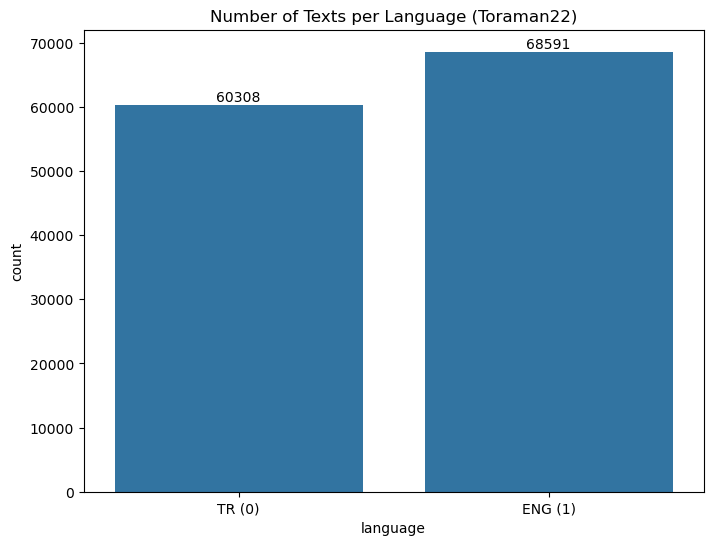

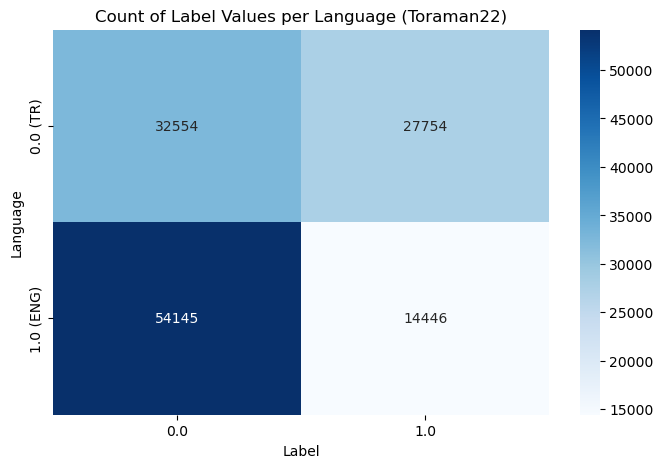

In [74]:
# 5. Visualize toraman22
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='language', data=toraman22)
ax.bar_label(ax.containers[0])
plt.title('Number of Texts per Language (Toraman22)')
plt.xticks(ticks=[0, 1], labels=['TR (0)', 'ENG (1)'])
plt.show()

# Heatmap for label column per language
heatmap_data = pd.crosstab(toraman22['language'], toraman22['label'])
heatmap_data.index = [f'{idx} (TR)' if idx == 0 else f'{idx} (ENG)' for idx in heatmap_data.index]
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues')
plt.title('Count of Label Values per Language (Toraman22)')
plt.ylabel('Language')
plt.xlabel('Label')
plt.show()

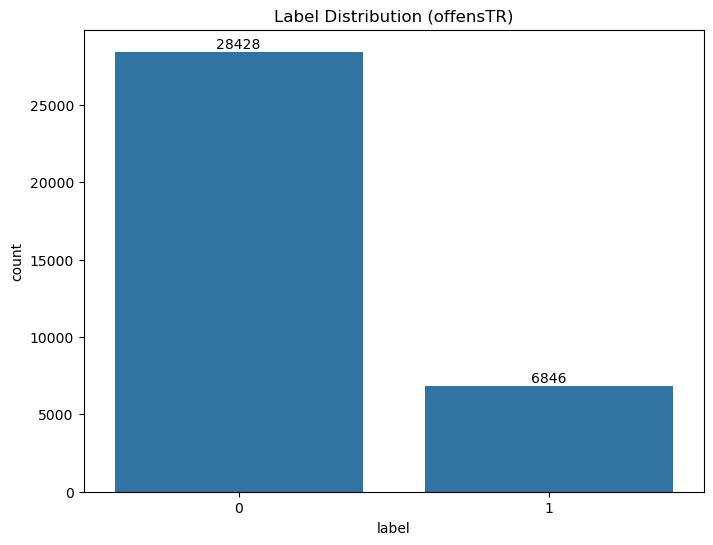

In [75]:
# 6. Visualize offensTR
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='label', data=offensTR)
ax.bar_label(ax.containers[0])
plt.title('Label Distribution (offensTR)')
plt.show()


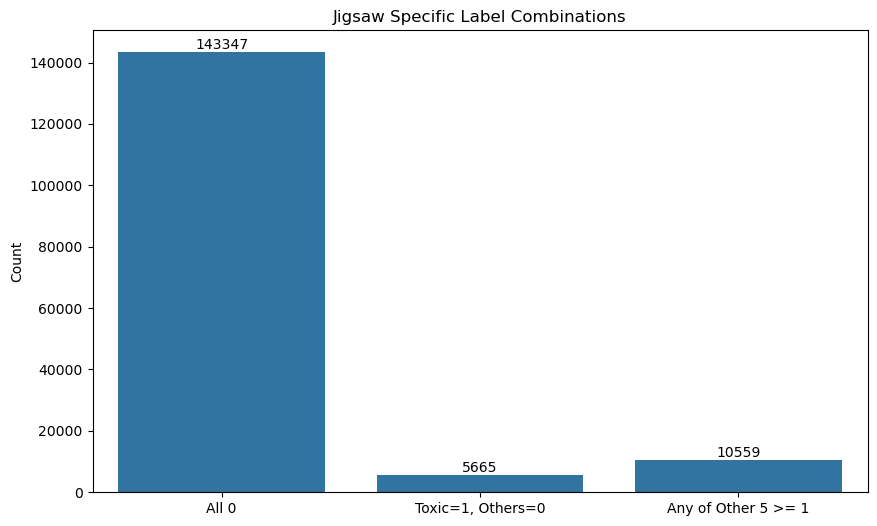

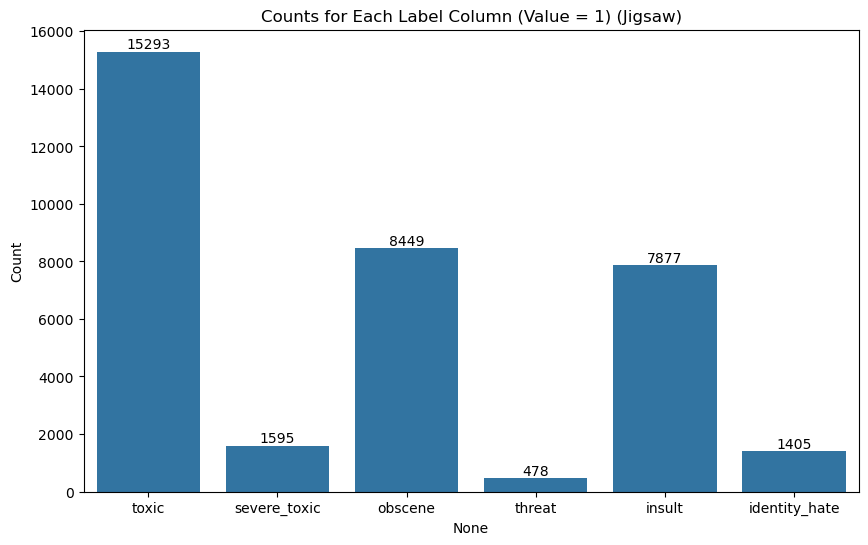

In [76]:
# 7. Visualize jigsaw
# Barplot 1
other_cols = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

all_zero = jigsaw[(jigsaw['toxic'] == 0) & (jigsaw[other_cols].sum(axis=1) == 0)].shape[0]
toxic_only = jigsaw[(jigsaw['toxic'] == 1) & (jigsaw[other_cols].sum(axis=1) == 0)].shape[0]
others_one = jigsaw[jigsaw[other_cols].sum(axis=1) > 0].shape[0]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=['All 0', 'Toxic=1, Others=0', 'Any of Other 5 >= 1'],
    y=[all_zero, toxic_only, others_one]
)
ax.bar_label(ax.containers[0])
plt.title('Jigsaw Specific Label Combinations')
plt.ylabel('Count')
plt.show()

# Barplot 2: Each bar for one column value = 1
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
counts = jigsaw[label_cols].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.index, y=counts.values)
ax.bar_label(ax.containers[0])
plt.title('Counts for Each Label Column (Value = 1) (Jigsaw)')
plt.ylabel('Count')
plt.show()

In [77]:
# 8. Create tempENG from Jigsaw
other_cols = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# 1. 'any value for toxic but at least 1 of the other 5 column to be value 1'
cond_1 = jigsaw[other_cols].sum(axis=1) >= 1
part1 = jigsaw[cond_1]

# 2. '1000 of toxic=1 and other 5=0'
cond_2 = (jigsaw['toxic'] == 1) & (jigsaw[other_cols].sum(axis=1) == 0)
part2 = jigsaw[cond_2].sample(n=1000, random_state=42)

# 3. '27000 of rows that have value 0 for all 6 columns'
cond_3 = (jigsaw['toxic'] == 0) & (jigsaw[other_cols].sum(axis=1) == 0)
part3 = jigsaw[cond_3].sample(n=28000, random_state=42)

tempENG = pd.concat([part1, part2, part3]).reset_index(drop=True)

# Collapse 6 columns into a single label column: 1 if any of them is 1, else 0
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
tempENG['label'] = (tempENG[label_cols].sum(axis=1) > 0).astype(int)

# Set language to 1 (ENG)
tempENG['language'] = 1

# Keep only required columns
tempENG = tempENG[['id', 'text', 'label', 'language']]

print('tempENG shape:', tempENG.shape)
print(tempENG.sample(5))

tempENG shape: (39559, 4)
                     id                                               text  \
30352  0d80936ce01bab91  Stewart International Airport \n\nPlease use {...   
20866  8965654ae389eb2d  "\n\n time does not match \n\ntime under the p...   
33733  f839ed05ae8f5c79  Interesting \n\nIt will be interesting to see ...   
26977  fd1ac5670fea64db  New article \n\nDo you think I should write a ...   
4022   a35a7a014182a283  Your stupidity \n\nAs you are aware, anything ...   

       label  language  
30352      0         1  
20866      0         1  
33733      0         1  
26977      0         1  
4022       1         1  


In [78]:
# 9. Create dataENG
# include all of tempENG
# toraman22's language = 1 and label = 1
t22_eng_label1 = toraman22[(toraman22['language'] == 1) & (toraman22['label'] == 1)][['id', 'text', 'label', 'language']]

# 32000 of toraman22's language = 1 and label = 0
t22_eng_label0 = toraman22[(toraman22['language'] == 1) & (toraman22['label'] == 0)].sample(n=33000, random_state=42)[['id', 'text', 'label', 'language']]

dataENG = pd.concat([tempENG, t22_eng_label1, t22_eng_label0]).reset_index(drop=True)

# 10. Create dataTR
offensTR_subset = offensTR[['id', 'text', 'label', 'language']]

t22_tr = toraman22[toraman22['language'] == 0][['id', 'text', 'label', 'language']]

dataTR = pd.concat([offensTR_subset, t22_tr]).reset_index(drop=True)

print('dataENG shape:', dataENG.shape)
print('dataTR shape:', dataTR.shape)


dataENG shape: (87005, 4)
dataTR shape: (95582, 4)


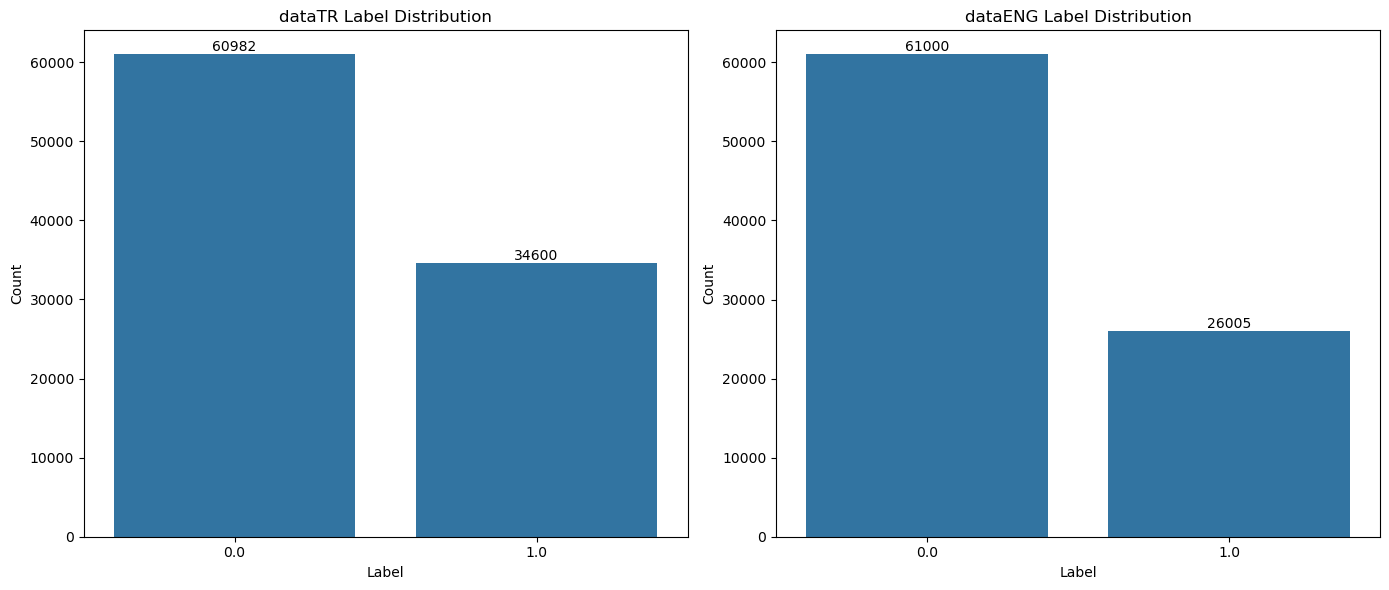

In [79]:
# 11. Visualize dataTR and dataENG
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = sns.countplot(x='label', data=dataTR, ax=axes[0])
ax1.set_title('dataTR Label Distribution')
ax1.bar_label(ax1.containers[0])
ax1.set_xlabel('Label')
ax1.set_ylabel('Count')

ax2 = sns.countplot(x='label', data=dataENG, ax=axes[1])
ax2.set_title('dataENG Label Distribution')
ax2.bar_label(ax2.containers[0])
ax2.set_xlabel('Label')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [80]:
# 12. Combine, shuffle, reassign IDs, and split into train/test
from sklearn.model_selection import train_test_split

# Combine dataTR and dataENG
final_df = pd.concat([dataTR, dataENG])

# Shuffle to ensure language=0 and language=1 are well mixed
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Reassign 'id' starting from 1
final_df['id'] = range(1, len(final_df) + 1)

# Stratified split (we stratify by both label and language to ensure distribution is consistent)
train_df, test_df = train_test_split(
    final_df, 
    test_size=0.2, 
    stratify=final_df[['label', 'language']], 
    random_state=42
)

# 13. Create the 4 CSV files (2 for Train, 2 for Test)
# 1. train data with id and text only
train_df[['id', 'text']].to_csv('training_datasets/train_text.csv', index=False)

# 2. train data with id, label, and language only
train_df[['id', 'label', 'language']].to_csv('training_datasets/train_labels.csv', index=False)

# 3. test data with id and text only
test_df[['id', 'text']].to_csv('testing_datasets/test_text.csv', index=False)

# 4. test data with id, label, and language only
test_df[['id', 'label', 'language']].to_csv('testing_datasets/test_labels.csv', index=False)

print('4 CSV files split by [text] and [labels] successfully created.')
print(f'Train size: {len(train_df)} | Test size: {len(test_df)}')


4 CSV files split by [text] and [labels] successfully created.
Train size: 146069 | Test size: 36518


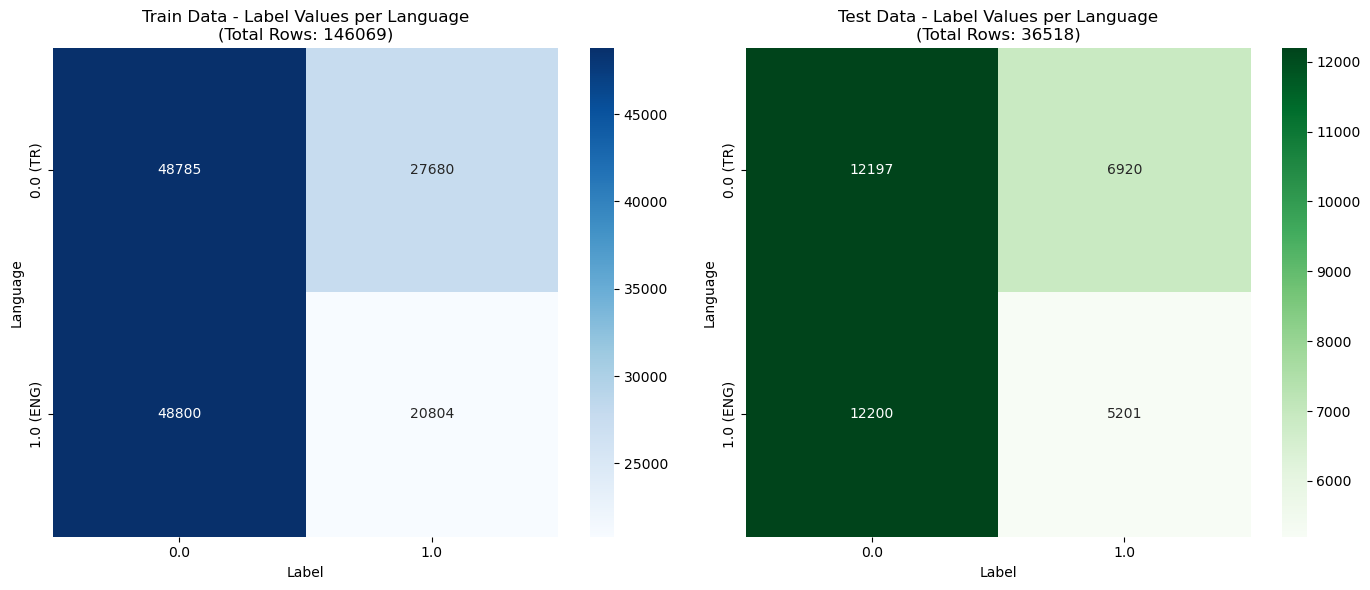

In [81]:
# 14. Visualize Counts of Label per Language from Saved CSV Splits
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Train Heatmap
train_heatmap = pd.crosstab(train_labels_df['language'], train_labels_df['label'])
train_heatmap.index = [f'{idx} (TR)' if idx == 0 else f'{idx} (ENG)' for idx in train_heatmap.index]
sns.heatmap(train_heatmap, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Train Data - Label Values per Language\n(Total Rows: {len(train_labels_df)})')
axes[0].set_ylabel('Language')
axes[0].set_xlabel('Label')

# 2. Test Heatmap
test_heatmap = pd.crosstab(test_labels_df['language'], test_labels_df['label'])
test_heatmap.index = [f'{idx} (TR)' if idx == 0 else f'{idx} (ENG)' for idx in test_heatmap.index]
sns.heatmap(test_heatmap, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Test Data - Label Values per Language\n(Total Rows: {len(test_labels_df)})')
axes[1].set_ylabel('Language')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()


In [82]:
# 15. Create FastText compatible datasets
# FastText format: __label__<class> <text>
import re

def clean_text_fasttext(text):
    text = str(text).lower()
    # Remove HTML tags
    text = re.sub('<[^<]+?>', '', text)
    # Remove newlines and extra spaces
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(' +', ' ', text).strip()
    return text

def to_fasttext_format(df, output_path):
    with open(output_path, 'w', encoding='utf-8') as f:
        for index, row in df.iterrows():
            text = clean_text_fasttext(row['text'])
            label = row['label']
            if text: # Avoid writing empty strings
                f.write(f'__label__{label} {text}\n')

print('Generating FastText format for training set...')
to_fasttext_format(train_df, 'training_datasets/train_fasttext.txt')

print('Generating FastText format for testing set...')
to_fasttext_format(test_df, 'testing_datasets/test_fasttext.txt')

print('FastText files saved successfully!')


Generating FastText format for training set...
Generating FastText format for testing set...
FastText files saved successfully!
